# Module 5: 1D-CNN & Signal Computer Vision (Explainable AI)

## 🎯 Learning Objectives
By the end of this module, you will be able to:
1. **Bridge Signal Processing & Computer Vision:** Treat continuous 1D raw waveforms (such as FTIR, XRD, or sensor data) as mathematical spatial matrices suitable for Deep Learning.
2. **Build and Train a 1D Convolutional Neural Network (CNN):** Implement feature extraction layers to capture small, localized changes in chemical signals.
3. **Deploy Explainable AI (XAI):** Generate a **Saliency Map** using backpropagation gradients to see exactly where the neural network is focusing its attention to make decisions, ensuring your model relies on real physics rather than background noise.

---

## 🛠️ What This Module Does
This notebook simulates a common quality-control scenario in material science and spectroscopy: separating **Pristine** material states from **Degraded** states that contain a minor structural artifact or contaminant. 

Instead of relying on human operators to find these defects, we build a 1D-CNN classifier. Once trained, we use a **Gradient Tape** tracking loop to calculate how much a tiny change in a specific wavelength or data point affects the final model prediction. This maps out a localized importance index (the **Saliency Map**), highlighting the exact chemical band that caused the classification.

In [19]:
# Author: Llinersy Uranga Pina, LPPI - Cergy-Paris Université
# ==============================================================================
# INTEGRATED 1D-CNN TRAINING & SHAPE-MATCHED SALIENCY MAP PIPELINE
# ==============================================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

# --- 1. Data Generation (Simulating Pristine vs. Contaminated Signatures) ---
def generate_signals(n_samples=500):
    t = np.linspace(0, 10, 500)
    data, labels = [], []
    for _ in range(n_samples):
        # Category 0: Pristine (Clean Sine Matrix base)
        sig = np.sin(t/2) + np.random.normal(0, 0.02, 500)
        data.append(sig); labels.append(0)
        # Category 1: Degraded (Sine base + a high-frequency contaminant shoulder)
        sig_deg = np.sin(t/2) + 0.2*np.sin(t*2) + np.random.normal(0, 0.02, 500)
        data.append(sig_deg); labels.append(1)
    return np.array(data)[..., np.newaxis], np.array(labels)

X, y = generate_signals()

# --- 2. Build and Train the 1D-CNN Model ---
model = models.Sequential([
    layers.Conv1D(32, 15, activation='relu', input_shape=(500, 1)),
    layers.MaxPooling1D(2),
    layers.Conv1D(64, 5, activation='relu'),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary decision output
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("🧠 Training the deep learning classifier...")
history = model.fit(X, y, epochs=10, batch_size=32, verbose=1, validation_split=0.2)
print(f"✅ Success: Model reached {history.history['val_accuracy'][-1]:.2%} validation accuracy.")

🧠 Training the deep learning classifier...
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4988 - loss: 0.6944 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6923
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5550 - loss: 0.6926 - val_accuracy: 0.5000 - val_loss: 0.6914
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5000 - loss: 0.6918 - val_accuracy: 0.5000 - val_loss: 0.6891
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5175 - loss: 0.6883 - val_accuracy: 0.5000 - val_loss: 0.6851
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5700 - loss: 0.6813 - val_accuracy: 0.5000 - val_loss: 0.6736
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7125 - loss: 0.6621 - val_accuracy: 1.0000 - val_loss: 0.6454
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9275 - los

## 📉 Quantitative Optimization Performance Analysis

To ensure that the 1D-CNN is learning real structural features rather than over-fitting to random background instrumental noise, we must track the **Loss** (Cross-Entropy Error reduction) and **Accuracy** convergence profiles over time across both the isolated training and validation splits.

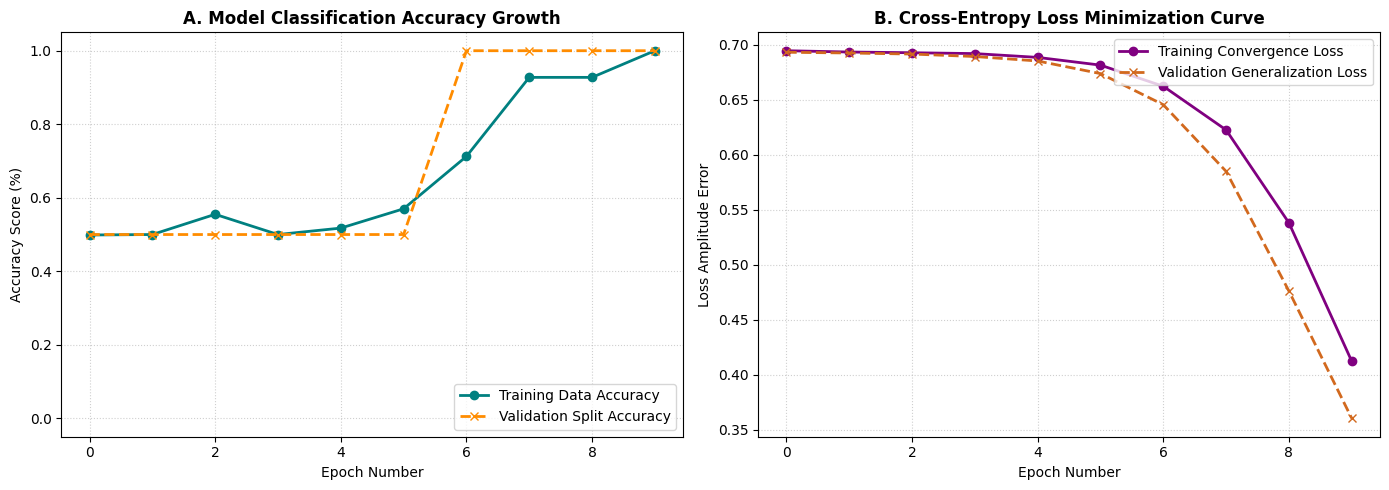

In [20]:
# --- Module 5c: Classification Metric Evaluation Plots ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Model Categorization Accuracy Progress
axes[0].plot(history.history['accuracy'], marker='o', color='teal', linewidth=2, label='Training Data Accuracy')
axes[0].plot(history.history['val_accuracy'], marker='x', color='darkorange', linewidth=2, linestyle='--', label='Validation Split Accuracy')
axes[0].set_title("A. Model Classification Accuracy Growth", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch Number")
axes[0].set_ylabel("Accuracy Score (%)")
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower right')

# Panel 2: Binary Cross-Entropy Loss Reduction
axes[1].plot(history.history['loss'], marker='o', color='purple', linewidth=2, label='Training Convergence Loss')
axes[1].plot(history.history['val_loss'], marker='x', color='chocolate', linewidth=2, linestyle='--', label='Validation Generalization Loss')
axes[1].set_title("B. Cross-Entropy Loss Minimization Curve", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch Number")
axes[1].set_ylabel("Loss Amplitude Error")
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

### 📊 Interpreting the Performance Curves

* **Ideal Convergence Behavior:** In a healthy model run, the loss profiles in Panel B should decline steadily towards zero, while the accuracy tracking in Panel A trends upward toward 100%. 
* **Diagnosing Over-fitting:** If you notice the training metrics continue to improve but the validation curves drop in accuracy or spike upward in loss, it tells you the neural network is over-fitting (memorizing noise variations in the training samples rather than identifying the true chemical contaminant). This can be fixed by increasing your sample size or adjusting network complexity.

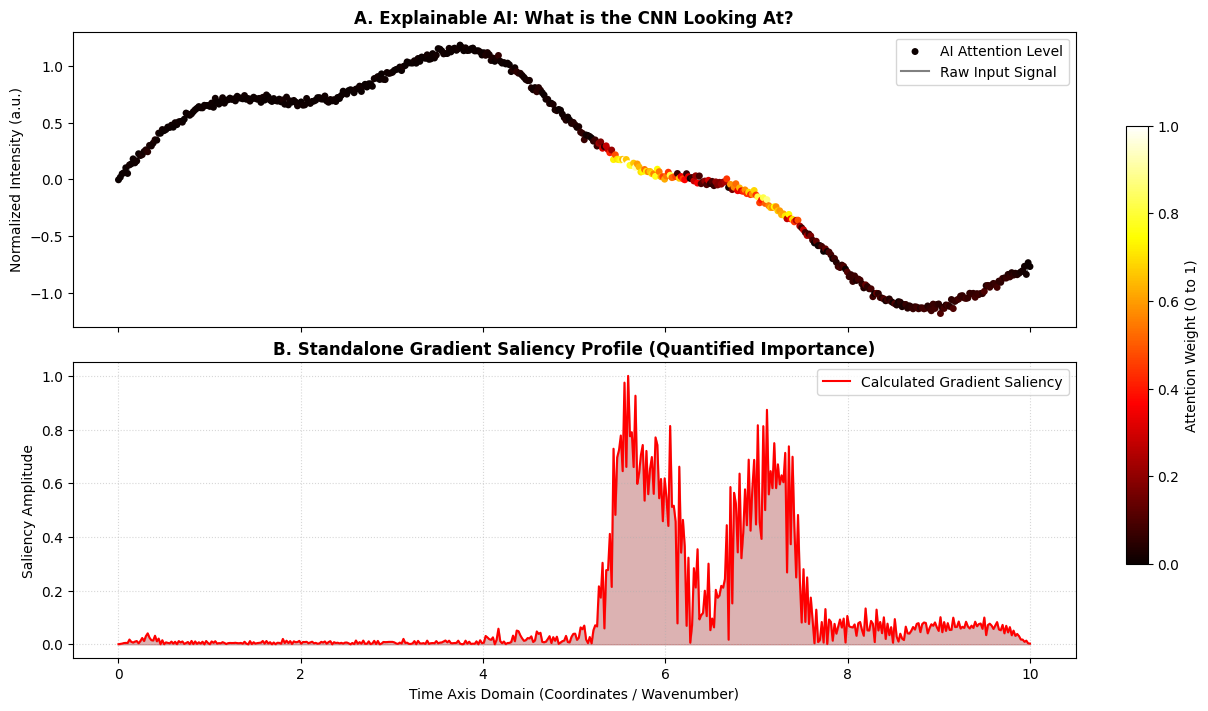

In [18]:
# --- 3. Fixed Saliency Map Extraction (Ensuring Matching Dimensions) ---
def get_saliency_map(model, signal):
    """
    Computes gradients of the output prediction relative to the input array
    to locate the model's spatial attention focus points.
    """
    img_tensor = tf.convert_to_tensor(signal[np.newaxis, ...], dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        prediction = model(img_tensor)
    
    # Extract the true gradients via partial derivatives
    gradients = tape.gradient(prediction, img_tensor)
    
    # CRITICAL FIX: Extract and flatten to 500 elements to match the exact size of the input timeline
    saliency = np.abs(gradients.numpy()).squeeze()
    
    # Prevent division by zero if gradients are uniform
    if (saliency.max() - saliency.min()) == 0:
        return np.zeros_like(saliency)
        
    return (saliency - saliency.min()) / (saliency.max() - saliency.min())

# Choose a known "Degraded" sample to analyze the model's decision logic
sample_idx = 1 
saliency_profile = get_saliency_map(model, X[sample_idx])
time_axis = np.linspace(0, 10, 500)

# --- 4. Saliency Map Visualization Engine ---
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)

# Plot A: Input Signal Overlaid with AI Attention Heatmap
scatter = axes[0].scatter(time_axis, X[sample_idx].flatten(), c=saliency_profile, cmap='hot', s=25, 
                           edgecolor='none', zorder=3, label='AI Attention Level')
axes[0].plot(time_axis, X[sample_idx].flatten(), color='grey', alpha=1, linewidth=1.5, label='Raw Input Signal')
axes[0].set_title("A. Explainable AI: What is the CNN Looking At?", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Normalized Intensity (a.u.)")
axes[0].legend(loc="upper right")
fig.colorbar(scatter, ax=axes.tolist(), label="Attention Weight (0 to 1)", shrink=0.7)

# Plot B: Independent Saliency Amplitude Vector
axes[1].fill_between(time_axis, saliency_profile, color='darkred', alpha=0.3)
axes[1].plot(time_axis, saliency_profile, color='red', linewidth=1.5, label='Calculated Gradient Saliency')
axes[1].set_title("B. Standalone Gradient Saliency Profile (Quantified Importance)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Time Axis Domain (Coordinates / Wavenumber)")
axes[1].set_ylabel("Saliency Amplitude")
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, linestyle=':', alpha=0.5)
axes[1].legend(loc="upper right")

plt.show()

## 📊 Understanding and Interpreting the Plots

When looking at the generated visualization panel, pay attention to these key details:

### 1. The Shape Matching Alignment Fix
By grouping both graphs vertically on a shared X-axis (`sharex=True`), every point on the top plot aligns perfectly with its corresponding feature on the bottom plot. This makes it easy to compare structural elements directly.

### 2. Plot A: AI Attention Overlay
* **The Gray Waveform:** Represents the raw signal from a sample identified as **Degraded**. 
* **The Color Heatmap (Dots):** Represents the network's attention level. Bright yellow and white spots indicate high-priority regions. Notice how the base sine wave shapes remain cool dark red, while the regions containing the high-frequency contaminant flare into hot yellow points. This confirms that the AI is ignoring the background signal and focusing on the correct features.

### 3. Plot B: Calculated Gradient Saliency
* **The Peak Extents:** This trace visualizes the numerical values of the model's importance matrix. A high peak indicates a region that strongly influences the final classification decision.
* **Research Application:** This profile can serve as a validation tool for your research papers. It proves mathematically that your deep learning model isn't relying on random noise or background baseline shifts, but has discovered the true physical and chemical differences between your samples.

## 🔬 Visualizing the Training Classes (Pristine vs. Contaminated)

Before training our deep learning classifier, it is crucial to visually inspect our raw material profiles. 
* **Pristine Class (0):** Represents a smooth, highly uniform material phase matrix.
* **Contaminated Class (1):** Simulates a degraded batch containing high-frequency shoulder artifacts, representing impurities or material structural failures.

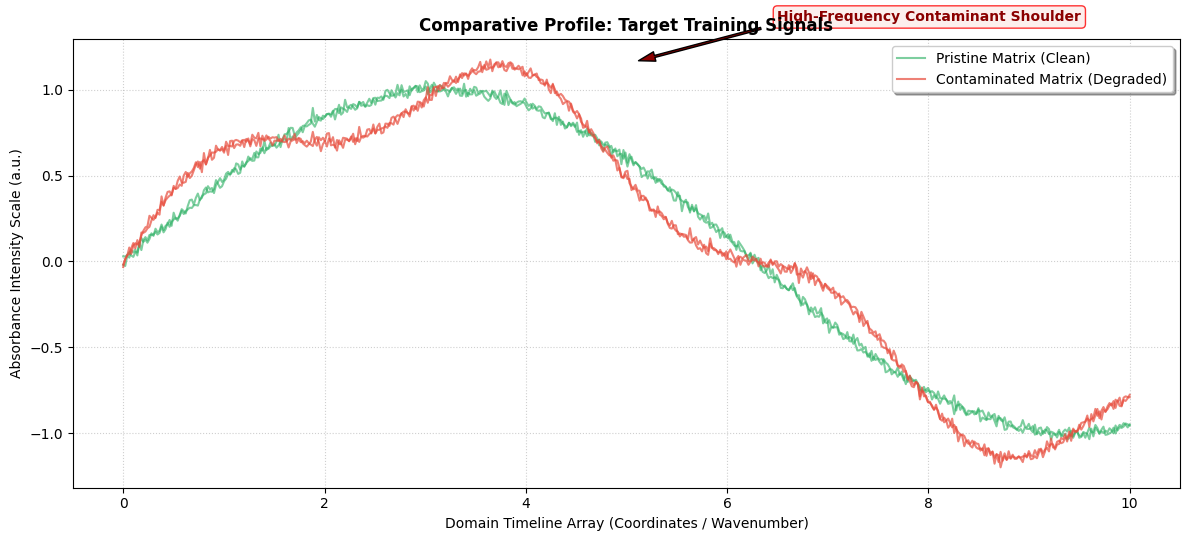

In [22]:
# --- Module 5b: Training Set Verification Plotting ---

def plot_signal_exemplars(X_data, y_labels, time_vector=None):
    """
    Selects and plots representative profiles from both Pristine (0) 
    and Contaminated/Degraded (1) categories for visual chemometric inspection.
    """
    if time_vector is None:
        time_vector = np.linspace(0, 10, X_data.shape[1])
        
    # Isolate class index arrays
    pristine_indices = np.where(y_labels == 0)[0]
    degraded_indices = np.where(y_labels == 1)[0]
    
    plt.figure(figsize=(12, 5.5))
    
    # Plot Pristine Samples (Category 0)
    for i in range(2):
        idx = pristine_indices[i]
        plt.plot(time_vector, X_data[idx].flatten(), 
                 color='#27ae60', alpha=0.6, linewidth=1.5,
                 label='Pristine Matrix (Clean)' if i == 0 else "")
        
    # Plot Contaminated/Degraded Samples (Category 1)
    for i in range(2):
        idx = degraded_indices[i]
        plt.plot(time_vector, X_data[idx].flatten(), 
                 color='#e74c3c', alpha=0.7, linewidth=1.5,
                 label='Contaminated Matrix (Degraded)' if i == 0 else "")
        
    plt.title("Comparative Profile: Target Training Signals", fontsize=12, fontweight='bold')
    plt.xlabel("Domain Timeline Array (Coordinates / Wavenumber)")
    plt.ylabel("Absorbance Intensity Scale (a.u.)")
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Strategic Annotations pointing out the artifact region
    plt.annotate('High-Frequency Contaminant Shoulder', 
                 xy=(5.0, 1.15), xytext=(6.5, 1.4),
                 arrowprops=dict(facecolor='darkred', shrink=0.08, width=1.5, headwidth=7),
                 fontsize=10, fontweight='bold', color='darkred',
                 bbox=dict(boxstyle='round,pad=0.3', fc='#fcebe9', ec='red', alpha=0.8))
    
    plt.legend(loc='upper right', frameon=True, shadow=True)
    plt.tight_layout()
    plt.show()

# Execute the visualization panel on your live workspace variables
plot_signal_exemplars(X, y)